# Cq vs N0 Quantitation Comparison

Compares two qPCR quantitation strategies applied to the same NfL-iPLA reactions:

- **Cq / Ct method** — standard threshold-crossing cycle number, converted to concentration via the standard-curve SLR
- **LinReg N0 (RDML)** — per-reaction efficiency-corrected initial fluorescence estimated by linear regression over the log-linear amplification phase

The goal is to determine whether efficiency correction materially affects concentration estimates in patient plasma, and whether matrix type (EDTA vs Li-Hep plasma) influences PCR efficiency.


## Setup

In [1]:
# ── Environment ───────────────────────────────────────────────────────────────
# ProxiPal is the project's custom stats/plotting library (ProxiPal.py, repo root).
# It re-exports pandas, numpy, scipy, and matplotlib — no separate imports needed.
import sys
from pathlib import Path

module_dir = Path.cwd().parent
sys.path.append(str(module_dir))

from ProxiPal import *  # noqa: F401,F403
# Repo: https://github.com/jeffsmith8/NfL-iPLA-paper

OS:				 Windows-11-10.0.26200-SP0
Python version:		 3.12.6 | packaged by conda-forge | (main, Sep 22 2024, 14:01:26) [MSC v.1941 64 bit (AMD64)]
Date and Time:		 2026-05-27 16:29:32
cwd:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\user_documents\NfL-PLA Development Paper\NfL-PLA Development Paper Figure Data\GitHub\NfL-iPLA-paper\NfL-iPLA_CqVsN0
base_path:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal
python_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\python
templates_folder:	 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\templates
data_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\data
samples_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\samples
quality_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\quality
user_downloads:		 C:\Users\smith.j\One

In [2]:
# ── Global rcParams ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.rcParams['font.family']        = 'sans-serif'
plt.rcParams['font.sans-serif']    = ['Helvetica', 'Arial']
plt.rcParams['font.size']          = 6
plt.rcParams['axes.titlesize']     = 6
plt.rcParams['axes.labelsize']     = 6
plt.rcParams['xtick.labelsize']    = 6
plt.rcParams['ytick.labelsize']    = 6
plt.rcParams['legend.fontsize']    = 6
plt.rcParams['axes.linewidth']     = 0.6
plt.rcParams['scatter.edgecolors'] = 'none'

In [3]:
# ── Okabe-Ito palette ─────────────────────────────────────────────────────────
okabe_ito = {
    'orange':         '#E69F00',
    'sky blue':       '#56B4E9',
    'bluish green':   '#009E73',
    'yellow':         '#F0E442',
    'blue':           '#0072B2',
    'vermillion':     '#D55E00',
    'reddish purple': '#CC79A7',
    'black':          '#000000',
}

matrix_colours = {
    'EDTA plasma':   okabe_ito['vermillion'],
    'Li-Hep plasma': okabe_ito['blue'],
}

## Load data

Each sample may have been run in duplicate reactions; samples tested more than once
produce 4+ rows. To avoid pseudo-replication, the first test of each sample is retained
and per-sample mean concentrations are used throughout.

In [4]:
CqVsN0 = pd.read_csv('Cq_vs_N0.csv')
CqVsN0.shape

(789, 124)

In [5]:
# Identify repeat-tested samples (>= 4 reactions = more than one test)
counts = CqVsN0.groupby(['sample_id', 'tube_id']).size()
print(counts[counts >= 4].reset_index(name='count').sort_values('count', ascending=False))

       sample_id  tube_id  count
8   NFL-QC-H[91]  missing     10
7     NFL-QC-087  missing      6
10  NFL-QC-M[19]  missing      6
9    NFL-QC-L[6]  missing      6
0        NFL-030  missing      4
1        NFL-031  missing      4
5        NFL-064  missing      4
4        NFL-059  missing      4
3        NFL-052  missing      4
2        NFL-033  missing      4
6        NFL-LoQ  missing      4
11       PSY 001  missing      4
12       PSY 003  missing      4
13       PSY 008  missing      4
14       PSY 009  missing      4
15       PSY 010  missing      4
16       PSY 012  missing      4
17       PSY 013  missing      4
18       PSY 015  missing      4
19       PSY 019  missing      4
20       PSY 020  missing      4
21       PSY 022  missing      4
22       PSY 027  missing      4
23       PSY 031  missing      4
24       PSY 038  missing      4
25       PSY 043  missing      4
26       PSY 044  missing      4
27       PSY 045  missing      4
28       PSY 047  missing      4
29       P

In [6]:
# Keep first test per sample; work with per-sample means
CqVsN0_f = CqVsN0.drop_duplicates(subset=['sample_id', 'tube_id'], keep='first')
CqVsN0_f.shape

(335, 124)

In [7]:
# Column aliases used throughout
X_COL = 'SLR; log10(x); exc_std0; ct; mean_ng/L'                                                          # Cq-based
Y_COL = 'SLR; log10(x); exc_std0; rdml_log2N0 (mean eff) - no plateau - stat efficiency; mean_ng/L'      # N0-based

## Passing–Bablok regression

Robust method-comparison regression; no distributional assumptions.
Slope = 1 and intercept = 0 indicates absence of both proportional and constant bias.

In [8]:
beta, alpha = passing_bablok(
    CqVsN0_f[X_COL].tolist(),
    CqVsN0_f[Y_COL].tolist()
)
print(f'Slope:     {beta[0]:.3f}  (95% CI {beta[1]:.3f}-{beta[2]:.3f})')
print(f'Intercept: {alpha[0]:.3f} (95% CI {alpha[1]:.3f}-{alpha[2]:.3f})')

Slope:     0.992  (95% CI 0.989-0.996)
Intercept: 0.042 (95% CI 0.001-0.078)


## Method-comparison scatter plots

Two views of the same data:
- **Autoscale** — data-driven axis limits
- **Fixed 0–200 pg/mL** — zooms to the clinically relevant range

In [9]:
from scipy.stats import spearmanr
from matplotlib.lines import Line2D
import matplotlib.markers as mmarkers

# Default marker cycle — all visually distinct at small sizes
_DEFAULT_MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X', 'h']

def plot_pb_scatter(ax, df, x_col, y_col, beta, alpha,
                   xlim=None, ylim=None, marker_style='open',
                   marker_map=None):
    """
    Passing-Bablok scatter with Spearman R, coloured by matrix type.

    marker_style:
        'open'   - open markers, full colour saturation, s=40, lw=0.6
        'filled' - filled markers, alpha=0.5, no edge

    marker_map : dict, optional
        {category_str: matplotlib_marker_spec}
        e.g. {'EDTA': 'o', 'CSF': 's', 'Serum': '^'}
        If None, markers are auto-assigned from _DEFAULT_MARKERS in
        category appearance order.
    """
    cats = df['collection_type'].fillna('NA').astype(str).unique()

    # Build marker map if not supplied
    if marker_map is None:
        marker_map = {cat: _DEFAULT_MARKERS[i % len(_DEFAULT_MARKERS)]
                      for i, cat in enumerate(cats)}

    handles = []
    for cat in cats:
        sub    = df[df['collection_type'].fillna('NA').astype(str) == cat]
        colour = matrix_colours.get(cat, okabe_ito['black'])
        marker = marker_map.get(cat, 'o')

        if marker_style == 'open':
            h = ax.scatter(
                sub[x_col], sub[y_col],
                s=40, marker=marker,
                facecolors='none', edgecolors=colour,
                linewidths=0.6, label=cat, zorder=3
            )
        else:  # filled
            h = ax.scatter(
                sub[x_col], sub[y_col],
                s=40, marker=marker, alpha=0.5,
                color=colour, edgecolors='none',
                label=cat, zorder=3
            )
        handles.append(h)

    ax.set_xlabel('NfL (pg/mL), Cq-derived')
    ax.set_ylabel('NfL (pg/mL), Log2(N0)-derived')
    if xlim:
        ax.set_xlim(*xlim)
    if ylim:
        ax.set_ylim(*ylim)

    x_range = np.linspace(*ax.get_xlim(), 200)
    ax.plot(x_range, x_range,
            color='#BBBBBB', linewidth=0.8, ls='--', zorder=1)
    ax.plot(x_range, beta[0] * x_range + alpha[0],
            color=okabe_ito['black'], linewidth=0.4, zorder=4)

    Rs, _ = spearmanr(df[x_col], df[y_col], nan_policy='omit')

    leg1 = ax.legend(handles=handles, title='Sample matrix', frameon=False, loc='upper left')
    ax.add_artist(leg1)

    stats_handles = [
        Line2D([0], [0], color='#BBBBBB', ls='--', linewidth=0.8, label='y = x'),
        Line2D([0], [0], color=okabe_ito['black'], linewidth=0.4,
               label=f'PB: {beta[0]:.2f}x + {alpha[0]:.2f}'),
        Line2D([0], [0], color='none', label=f'Spearman R = {Rs:.2f}'),
    ]
    ax.legend(handles=stats_handles, frameon=False, loc='lower right')
    ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)

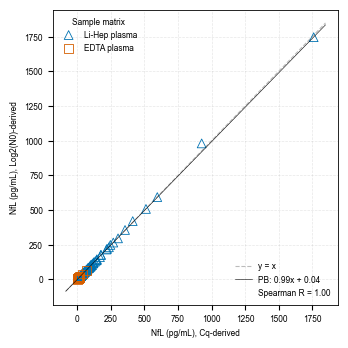

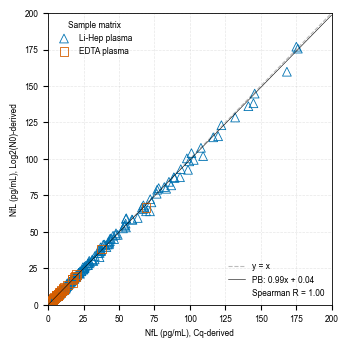

In [10]:
# _DEFAULT_MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X', 'h']

my_marker_map = {
    'Li-Hep plasma':  '^',
    'EDTA plasma':   's',
#     'Serum': 'o',
}

for xlim, ylim, suffix in [
    (None,      None,      'autoscale'),
    ((0, 200),  (0, 200),  '0_200'),
]:
    fig, ax = plt.subplots(figsize=(88/25.4, 88/25.4))
    plot_pb_scatter(ax, CqVsN0_f, X_COL, Y_COL, beta, alpha,
                   xlim=xlim, ylim=ylim, marker_style='open',
                   marker_map=my_marker_map)
    plt.tight_layout()
    plt.savefig(f'fig_cq_vs_n0_{suffix}_open.svg', dpi=300, bbox_inches='tight')
    plt.show()

## Bland–Altman analysis

Percent difference plot: (Cq − N0) / mean × 100.
X-axis log-scaled to span the full concentration range.
Limits of agreement: mean bias ± 1.96 SD.

In [12]:
x = CqVsN0_f[X_COL]
y = CqVsN0_f[Y_COL]
mean_vals = (x + y) / 2
pct_diff  = (x - y) / mean_vals * 100
mean_bias = pct_diff.mean()
loa       = 1.96 * pct_diff.std()

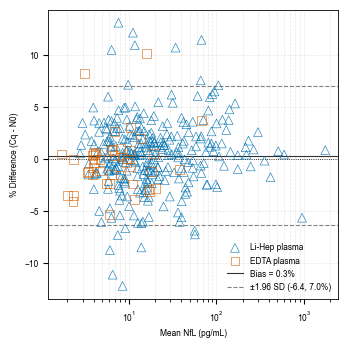

In [13]:
fig, ax = plt.subplots(figsize=(88/25.4, 88/25.4))
handles = []
for cat, marker in my_marker_map.items():
    mask   = CqVsN0_f['collection_type'].fillna('NA').astype(str) == cat
    colour = matrix_colours.get(cat, okabe_ito['black'])
    h = ax.scatter(
        mean_vals[mask], pct_diff[mask],
        s=40, marker=marker,
        facecolors='none', edgecolors=colour,
        linewidths=0.4, label=cat, zorder=3
    )
    handles.append(h)

ax.axhline(mean_bias,       color='#333333', linewidth=0.8)
ax.axhline(mean_bias + loa, color='grey',    linewidth=0.8, linestyle='--')
ax.axhline(mean_bias - loa, color='grey',    linewidth=0.8, linestyle='--')
ax.axhline(0, color=okabe_ito['black'], linewidth=0.6, linestyle=':')

# Append reference line entries to same handle list
handles += [
    Line2D([0], [0], color='#333333', linewidth=0.8,
           label=f'Bias = {mean_bias:.1f}%'),
    Line2D([0], [0], color='grey', linewidth=0.8, linestyle='--',
           label=f'±1.96 SD ({mean_bias - loa:.1f}, {mean_bias + loa:.1f}%)'),
#     Line2D([0], [0], color=okabe_ito['black'], linewidth=0.6, linestyle=':',
#            label='Zero'),
]

ax.set_xlabel('Mean NfL (pg/mL)')
ax.set_ylabel('% Difference (Cq - N0)')
ax.set_xscale('log')
ax.legend(handles=handles, frameon=False, loc='lower right')
ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.savefig('fig_cq_vs_n0_BA.svg', dpi=300, bbox_inches='tight')
plt.show()

## Lin's concordance correlation coefficient (CCC)

CCC combines Pearson correlation (precision) with proximity to the identity line (accuracy).
Values > 0.99 indicate near-perfect method agreement.

In [14]:
import torch
from torchmetrics.functional.regression import concordance_corrcoef

preds  = torch.tensor(y.values, dtype=torch.float32)
target = torch.tensor(x.values, dtype=torch.float32)

if torch.cuda.is_available():
    preds, target = preds.cuda(), target.cuda()

ccc = concordance_corrcoef(preds, target)
print(f"Lin's CCC: {ccc.cpu().item():.4f}")

Lin's CCC: 0.9996


## TOST equivalence test

Two one-sided t-tests assess whether the mean method difference falls within ±10% of
the grand mean concentration. A significant overall p (< 0.05) supports equivalence.

In [15]:
from statsmodels.stats.weightstats import ttost_paired

method1 = x.values   # Cq-based
method2 = y.values   # N0-based

grand_mean = np.mean((method1 + method2) / 2)
eq_bound   = 0.10 * grand_mean   # ±10% equivalence margin

overall_p, lower_result, upper_result = ttost_paired(method1, method2, -eq_bound, eq_bound)

tstat_low, pval_low, _ = lower_result
tstat_upp, pval_upp, _ = upper_result

print(f'Equivalence bounds: +/-{eq_bound:.2f} pg/mL (10% of grand mean {grand_mean:.1f} pg/mL)')
print(f'Lower bound test:   t = {tstat_low:.3f}, p = {pval_low:.4g}')
print(f'Upper bound test:   t = {tstat_upp:.3f}, p = {pval_upp:.4g}')
print(f'Overall TOST p:     {overall_p:.4g}')
print('Equivalent' if overall_p < 0.05 else 'Not equivalent', 'within bounds')

Equivalence bounds: +/-4.28 pg/mL (10% of grand mean 42.8 pg/mL)
Lower bound test:   t = 23.702, p = 7.697e-74
Upper bound test:   t = -21.915, p = 6.612e-67
Overall TOST p:     6.612e-67
Equivalent within bounds


## PCR efficiency by matrix type

Compares per-reaction LinReg PCR efficiency across diluent (standard curve), EDTA plasma,
and Li-Hep plasma. Matrix-induced inhibition would manifest as systematically lower
efficiency in plasma relative to diluent.

In [16]:
# Standards (diluent) from matching experiment runs — not included in CqVsN0.csv
CqVsN0_std = pd.read_csv('Cq_vs_N0_std.csv')
CqVsN0_std.shape

(167, 124)

In [17]:
# Deduplicate standards to match the sample deduplication approach
CqVsN0_std_f = CqVsN0_std.drop_duplicates(subset=['filepath_txt', 'rep_id'], keep='first')

# Combine diluent (standards) and plasma (samples)
CqVsN0_concat = pd.concat([CqVsN0_std_f, CqVsN0_f], axis=0).reset_index(drop=True)
CqVsN0_concat.shape

(419, 124)

In [18]:
EFF_COL = 'mean rdml_indiv PCR eff'

diluent_eff = CqVsN0_concat[CqVsN0_concat['collection_type'] == 'Diluent'][EFF_COL]
lihep_eff   = CqVsN0_concat[CqVsN0_concat['collection_type'] == 'Li-Hep plasma'][EFF_COL]
edta_eff    = CqVsN0_concat[CqVsN0_concat['collection_type'] == 'EDTA plasma'][EFF_COL]

print(f'n: Diluent = {len(diluent_eff)}, Li-Hep = {len(lihep_eff)}, EDTA = {len(edta_eff)}')

n: Diluent = 84, Li-Hep = 290, EDTA = 45


## One-way ANOVA and Tukey HSD

Tests whether mean PCR efficiency differs across matrix groups; Tukey HSD provides
family-wise error-corrected pairwise comparisons.

In [19]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

anova_df = pd.DataFrame({
    'value': np.concatenate([diluent_eff, lihep_eff, edta_eff]),
    'group': (['Diluent']  * len(diluent_eff) +
              ['Li-Hep']   * len(lihep_eff)   +
              ['EDTA']     * len(edta_eff))
})

f_stat, p_anova = stats.f_oneway(diluent_eff, lihep_eff, edta_eff)
print(f'One-way ANOVA: F = {f_stat:.4f}, p = {p_anova:.4e}')

tukey = pairwise_tukeyhsd(endog=anova_df['value'], groups=anova_df['group'], alpha=0.05)
print(tukey)

One-way ANOVA: F = 32.8554, p = 5.6472e-14
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower   upper  reject
-----------------------------------------------------
Diluent   EDTA   0.0261    0.0  0.0127  0.0395   True
Diluent Li-Hep  -0.0128 0.0026 -0.0218 -0.0038   True
   EDTA Li-Hep  -0.0389    0.0 -0.0505 -0.0272   True
-----------------------------------------------------


In [20]:
# Extract per-pair p-values for figure annotation
comparisons = list(zip(
    tukey._multicomp.groupsunique[tukey._multicomp.pairindices[0]],
    tukey._multicomp.groupsunique[tukey._multicomp.pairindices[1]]
))
for (g1, g2), p in zip(comparisons, tukey.pvalues):
    print(f'{g1} vs {g2}: p = {p:.4g}')

Diluent vs EDTA: p = 1.934e-05
Diluent vs Li-Hep: p = 0.002589
EDTA vs Li-Hep: p = 1.653e-13


## PCR efficiency strip plot

Jittered strip with mean ± SD overlay and Tukey-corrected significance brackets.
Viridis density colouring highlights overplotted regions.

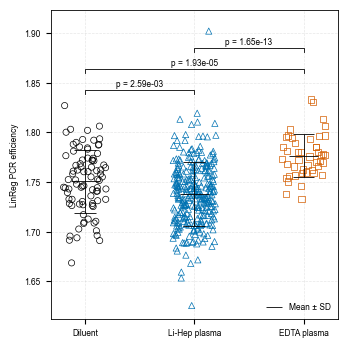

In [21]:
CAT_ORDER = ['Diluent', 'Li-Hep plasma', 'EDTA plasma']
GAP       = 0.3
xpos      = {cat: i * GAP for i, cat in enumerate(CAT_ORDER)}
df_eff    = CqVsN0_concat[CqVsN0_concat['collection_type'].isin(CAT_ORDER)].copy()

fig, ax = plt.subplots(figsize=(88/25.4, 88/25.4))

marker_map_eff = {
    'Diluent':       ('o', okabe_ito['black']),
    'Li-Hep plasma': ('^', matrix_colours['Li-Hep plasma']),
    'EDTA plasma':   ('s', matrix_colours['EDTA plasma']),
}

# ── Per-category jitter scatter ───────────────────────────────────────────────
rng = np.random.default_rng(42)
for cat in CAT_ORDER:
    mask           = df_eff['collection_type'] == cat
    y              = df_eff.loc[mask, EFF_COL].to_numpy()
    x              = np.full(len(y), xpos[cat]) + rng.uniform(-0.06, 0.06, size=len(y))
    marker, colour = marker_map_eff[cat]
    ax.scatter(x, y,
               s=20, marker=marker,
               facecolors='none', edgecolors=colour,
               linewidths=0.5, zorder=2)

# ── Mean ± SD ─────────────────────────────────────────────────────────────────
# for cat in CAT_ORDER:
#     grp            = df_eff[df_eff['collection_type'] == cat][EFF_COL]
#     m, s           = grp.mean(), grp.std()
#     marker, colour = marker_map_eff[cat]
#     # Error bar stem
#     ax.vlines(xpos[cat], m - s, m + s,
#               color=okabe_ito['black'], linewidth=0.6, zorder=3)
#     # Mean crossbar
#     ax.hlines(m, xpos[cat] - 0.04, xpos[cat] + 0.04,
#               color=okabe_ito['black'], linewidth=0.6, zorder=4,
#               label='Mean ± SD' if cat == CAT_ORDER[0] else None)

for cat in CAT_ORDER:
    grp  = df_eff[df_eff['collection_type'] == cat][EFF_COL]
    m, s = grp.mean(), grp.std()
    # Stem
    ax.vlines(xpos[cat], m - s, m + s,
              color=okabe_ito['black'], linewidth=0.6, zorder=3)
    # Caps
    ax.hlines([m - s, m + s], xpos[cat] - 0.03, xpos[cat] + 0.03,
              color=okabe_ito['black'], linewidth=0.6, zorder=3)
    # Mean crossbar — slightly wider and heavier than caps
    ax.hlines(m, xpos[cat] - 0.04, xpos[cat] + 0.04,
              color=okabe_ito['black'], linewidth=0.6, zorder=4,
              label='Mean ± SD' if cat == CAT_ORDER[0] else None)
    
# ── Significance bars ─────────────────────────────────────────────────────────
sig_pairs = {
    ('Diluent', 'Li-Hep plasma'):     2.59e-03,
    ('Diluent', 'EDTA plasma'):       1.93e-05,
    ('Li-Hep plasma', 'EDTA plasma'): 1.65e-13,
}
yl   = list(ax.get_ylim())
step = (yl[1] - yl[0]) * 0.07
base = 1.86 - step  # anchors middle pair (i=1) at y = 1.88

for i, ((g1, g2), p) in enumerate(sig_pairs.items()):
    x1, x2 = xpos[g1], xpos[g2]
    y_bar   = base + i * step
    ax.plot([x1, x1, x2, x2],
            [y_bar, y_bar + step * 0.2, y_bar + step * 0.2, y_bar],
            color=okabe_ito['black'], linewidth=0.6)
    ax.text((x1 + x2) / 2, y_bar + step * 0.25,
            f'p = {p:.2e}', ha='center', va='bottom')

ax.set_ylim(yl[0], base + len(sig_pairs) * step + step)
ax.set_xticks([xpos[c] for c in CAT_ORDER])
ax.set_xticklabels(CAT_ORDER)
ax.set_ylabel('LinReg PCR efficiency')
ax.legend(frameon=False, loc='lower right')
ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.savefig('fig_pcr_efficiency_matrix.svg', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# fig, ax = plt.subplots(figsize=(88/25.4, 88/25.4))

# marker_map_eff = {
#     'Diluent':       ('o', okabe_ito['black']),
#     'EDTA plasma':   ('s', matrix_colours['EDTA plasma']),
#     'Li-Hep plasma': ('^', matrix_colours['Li-Hep plasma']),
# }

# # ── Per-category jitter scatter ───────────────────────────────────────────────
# rng = np.random.default_rng(42)
# for cat in CAT_ORDER:
#     mask   = df_eff['collection_type'] == cat
#     y      = df_eff.loc[mask, EFF_COL].to_numpy()
#     x      = np.full(len(y), xpos[cat]) + rng.uniform(-0.06, 0.06, size=len(y))
#     marker, colour = marker_map_eff[cat]
#     ax.scatter(x, y,
#                s=20, marker=marker,
#                facecolors='none', edgecolors=colour,
#                linewidths=0.5, zorder=2)

# # ── Mean ± SD ─────────────────────────────────────────────────────────────────
# for cat in CAT_ORDER:
#     grp            = df_eff[df_eff['collection_type'] == cat][EFF_COL]
#     m, s           = grp.mean(), grp.std()
#     marker, colour = marker_map_eff[cat]
#     ax.errorbar(xpos[cat], m, yerr=s,
#                 fmt=marker,
#                 markerfacecolor='none',
#                 markeredgecolor=okabe_ito['black'],
#                 ecolor=okabe_ito['black'],
#                 elinewidth=0.8, capsize=4, markersize=4, zorder=3,
#                 label='Mean ± SD' if cat == CAT_ORDER[0] else None)

# # ── Significance bars ─────────────────────────────────────────────────────────
# sig_pairs = {
#     ('Diluent', 'EDTA plasma'):       1.93e-05,
#     ('Diluent', 'Li-Hep plasma'):     2.59e-03,
#     ('EDTA plasma', 'Li-Hep plasma'): 1.65e-13,
# }
# yl   = list(ax.get_ylim())
# base = yl[1] + (yl[1] - yl[0]) * 0.04
# step = (yl[1] - yl[0]) * 0.07
# for i, ((g1, g2), p) in enumerate(sig_pairs.items()):
#     x1, x2 = xpos[g1], xpos[g2]
#     y_bar   = base + i * step
#     ax.plot([x1, x1, x2, x2],
#             [y_bar, y_bar + step * 0.2, y_bar + step * 0.2, y_bar],
#             color=okabe_ito['black'], linewidth=0.6)
#     ax.text((x1 + x2) / 2, y_bar + step * 0.25,
#             f'p = {p:.2e}', ha='center', va='bottom')

# ax.set_ylim(yl[0], base + len(sig_pairs) * step + step)
# ax.set_xticks([xpos[c] for c in CAT_ORDER])
# ax.set_xticklabels(CAT_ORDER)
# ax.set_ylabel('LinReg PCR efficiency')
# ax.legend(frameon=False, loc='upper left')
# ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)
# plt.tight_layout()
# plt.savefig('fig_pcr_efficiency_matrix.svg', dpi=300, bbox_inches='tight')
# plt.show()

In [23]:
# from scipy.stats import gaussian_kde
# import matplotlib.cm as cm
# import matplotlib.colors as mcolors

# CAT_ORDER = ['Diluent', 'EDTA plasma', 'Li-Hep plasma']

# df_eff = CqVsN0_concat[CqVsN0_concat['collection_type'].isin(CAT_ORDER)].copy()

# # Compressed x positions — avoids large whitespace between categories
# GAP    = 0.3
# xpos   = {cat: i * GAP for i, cat in enumerate(CAT_ORDER)}
# x_base = df_eff['collection_type'].map(xpos).astype(float).to_numpy()
# y_vals = df_eff[EFF_COL].to_numpy()

# rng      = np.random.default_rng(42)
# x_jitter = x_base + rng.uniform(-0.06, 0.06, size=len(df_eff))

# # KDE for density colouring
# density = gaussian_kde(np.vstack([x_jitter, y_vals]))(np.vstack([x_jitter, y_vals]))
# norm    = mcolors.Normalize(vmin=density.min(), vmax=density.max())

# fig, ax = plt.subplots(figsize=(88/25.4, 80/25.4))

# ax.scatter(x_jitter, y_vals,
#            c=density, cmap=cm.viridis, norm=norm,
#            s=8, alpha=0.8, edgecolors='none', zorder=2)

# # Mean +/- SD per group
# for cat in CAT_ORDER:
#     grp  = df_eff[df_eff['collection_type'] == cat][EFF_COL]
#     m, s = grp.mean(), grp.std()
#     ax.errorbar(xpos[cat], m, yerr=s,
#                 fmt='o', color=okabe_ito['black'],
#                 elinewidth=0.8, capsize=4, markersize=4, zorder=3,
#                 label='Mean +/- SD' if cat == CAT_ORDER[0] else None)

# ax.set_xticks([xpos[c] for c in CAT_ORDER])
# ax.set_xticklabels(CAT_ORDER)
# ax.set_ylabel('LinReg PCR efficiency')
# ax.legend(frameon=False, loc='upper left')
# ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)

# # Tukey-corrected p-values from pairwise analysis above
# sig_pairs = {
#     ('Diluent', 'EDTA plasma'):       1.93e-05,
#     ('Diluent', 'Li-Hep plasma'):     2.59e-03,
#     ('EDTA plasma', 'Li-Hep plasma'): 1.65e-13,
# }

# yl   = list(ax.get_ylim())
# base = yl[1] + (yl[1] - yl[0]) * 0.04
# step = (yl[1] - yl[0]) * 0.07

# for i, ((g1, g2), p) in enumerate(sig_pairs.items()):
#     x1, x2 = xpos[g1], xpos[g2]
#     y_bar   = base + i * step
#     ax.plot([x1, x1, x2, x2],
#             [y_bar, y_bar + step * 0.2, y_bar + step * 0.2, y_bar],
#             color=okabe_ito['black'], linewidth=0.6)
#     ax.text((x1 + x2) / 2, y_bar + step * 0.25,
#             f'p = {p:.2e}', ha='center', va='bottom')

# ax.set_ylim(yl[0], base + len(sig_pairs) * step + step)

# plt.tight_layout()
# plt.savefig('fig_pcr_efficiency_matrix.svg', dpi=300, bbox_inches='tight')
# plt.show()